## Analysis of Forman-Ricci Curvature in Directed Networks and Its Application in SIR Models

This Notebook delves into the computation of Forman-Ricci curvature for directed networks and its utilization in network-based SIR (Susceptible-Infected-Recovered) models. The implementation focuses on understanding how network topology, as defined by Forman-Ricci curvature, influences disease dynamics. The notebook includes updates for a broader range of directed network models and integrates simulations of traditional and curvature-dependent SIR models.

### Contents

1. **Computation of Forman-Ricci Curvature for Directed Networks**  
   - Implemented for various directed network models, including:
     - Erdős-Rényi Model
     - Watts-Strogatz Model
     - Scale-Free Model
     - Power-Law Cluster Model
   - Curvature computed for all edges, and node-level Forman curvatures (in and out) are derived.

2. **Visualization of Curvature Distributions**  
   - Distribution histograms for In-Forman and Out-Forman curvatures for each network model.
   - Color-coded visualizations enhance understanding of curvature characteristics in different topologies.

3. **Correlation Analysis Between Curvature and Centrality Measures**  
   - Analyzes relationships between Forman-Ricci curvatures (in and out) and:
     - Node in-degree and out-degree
     - Clustering coefficients
     - Betweenness centrality
   - Results plotted with Pearson correlation coefficients.

4. **Simulation of SIR Models with Curvature-Dependent Transmission Rates**  
   - Transmission rates adjusted using curvature-dependent expressions:  
     
     $$\beta_{ij} := \beta_0 \cdot \exp(F(e))$$
      
   - Simulates and plots the dynamics of susceptible, infected, and recovered compartments over time for each network model.

5. **Comparison with Traditional SIR Models**  
   - Simulations of the traditional SIR model using constant transmission rates.
   - Comparative plots showing differences between traditional and curvature-dependent models across multiple $\beta_0$ values.

6. **Network Models**  
   - Directed versions of the following networks:
     - **Erdős-Rényi Model:** Random graph with \( n = 1000 \) nodes and edge creation probability \( p = 0.003 \).
     - **Watts-Strogatz Model:** Small-world network with \( n = 1000 \) nodes, \( k = 10 \) nearest neighbors, and rewiring probability \( p = 0.1 \).
     - **Scale-Free Model:** Generated using the Directed Configuration Model with in-degree and out-degree power-law distributions.
     - **Power-Law Cluster Model:** Directed version with \( n = 1000 \), \( m = 3 \) edges, and triangle probability \( p = 0.05 \).

### Key Features

- **Reusable Simulation Functions:** Unified methods to compute curvature, simulate SIR dynamics, and plot results for all network models.
- **Dynamic Analysis:** Explores how topology influences disease spread, validated through SIR dynamics visualizations.
- **Enhanced Plotting:** Subplots for SIR dynamics (S, I, R compartments) and curvature-centrality correlations.

This implementation serves as a comprehensive toolkit for analyzing curvature's role in epidemic modeling, applicable to diverse network structures.

In [6]:
# Libraries and Setup
import sys
import os
sys.path.append(os.path.abspath('..'))  # adjust if needed
from frc_lib.directed_frc import FormanRicciDirected
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('ggplot')
from scipy.stats import pearsonr
from scipy.integrate import odeint
# Set seed for reproducibility
np.random.seed(42)

### 1. Computation of Forman-Ricci Curvature for Directed Networks

### 2. Visualization of Curvature Distributions

In [7]:
def plot_curvature_distributions(G, model_name, in_color, out_color):
    fr = FormanRicciDirected(G)
    G_with_curvature = fr.compute_ricci_curvature()
    G_with_curvature = fr.compute_node_curvatures()

    in_curvatures = [G_with_curvature.nodes[n]["FormanCurvatureIn"] for n in G_with_curvature.nodes()]
    out_curvatures = [G_with_curvature.nodes[n]["FormanCurvatureOut"] for n in G_with_curvature.nodes()]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi = 100)
    axs = axs.flatten()  # Flatten the array for easy iteration
    # Plot In Forman-Ricci curvature distribution
    axs[0].hist(in_curvatures, bins=100, color=in_color, alpha=0.7) #, label='In Forman-Ricci Curvature'
    axs[0].set_title(f'{model_name}')
    axs[0].set_xlabel('In FRC')
    axs[0].set_ylabel('Frequency')
    #axs[0].legend()
    #axs[0].grid(True)

    # Plot Out Forman-Ricci curvature distribution
    axs[1].hist(out_curvatures, bins=100, color=out_color, alpha=0.7) #, label='Out Forman-Ricci Curvature'
    axs[1].set_title(f'{model_name}')
    axs[1].set_xlabel('Out FRC')
    axs[1].set_ylabel('Frequency')
    #axs[1].legend()
    #axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
def generate_power_law_sequence(n, exponent, minimum=1):
    """Generate a power-law sequence."""
    return (np.random.pareto(exponent - 1, n) + minimum).astype(int)

def directed_scale_free_network(n, lambda_in, lambda_out):
    """
    Generate a directed scale-free network using the Directed Configuration Model.
    """
    # Generate in-degree and out-degree sequences
    in_degrees = generate_power_law_sequence(n, lambda_in)
    out_degrees = generate_power_law_sequence(n, lambda_out)

    # Ensure the sum of in-degrees and out-degrees are the same
    while sum(in_degrees) != sum(out_degrees):
        in_degrees = generate_power_law_sequence(n, lambda_in)
        out_degrees = generate_power_law_sequence(n, lambda_out)

    # Use the directed configuration model to generate the network
    G = nx.directed_configuration_model(in_degrees, out_degrees)
    G = nx.DiGraph(G)  # Convert to directed graph
    G.remove_edges_from(nx.selfloop_edges(G))  # Remove self-loops

    return G

def directed_watts_strogatz_network(n, k, p):
    """
    Generate a directed Watts-Strogatz small-world network.
    """
    G = nx.watts_strogatz_graph(n, k, p)  # Generate undirected Watts-Strogatz network
    G = nx.DiGraph(G)  # Convert to directed graph
    G = nx.DiGraph((u, v) for u, v in G.edges() if np.random.rand() < 0.5)  # Randomly orient edges

    return G

def directed_power_law_cluster_network(n, m, p):
    """
    Generate a directed Power-law Cluster network.
    """
    G = nx.powerlaw_cluster_graph(n, m, p)  # Generate undirected Power-law Cluster network
    G = nx.DiGraph(G)  # Convert to directed graph
    G = nx.DiGraph((u, v) for u, v in G.edges() if np.random.rand() < 0.5)  # Randomly orient edges

    return G

def directed_erdos_renyi_network(n, p):
    """
    Generate a directed Erdős-Rényi network.
    """
    G = nx.erdos_renyi_graph(n, p, directed=True)  # Directly generate directed Erdős-Rényi graph

    return G

In [9]:
# Parameters for generating graphs
n = 1000  # Number of nodes
k = 10  # Each node is connected to k nearest neighbors (for Watts-Strogatz)
p_ws = 0.1  # Rewiring probability for Watts-Strogatz
m = 3  # Number of edges to attach from a new node to existing nodes (for Power-law Cluster)
p_plc = 0.05  # Probability of forming a triangle (for Power-law Cluster)
lambda_in = 2.1  # Exponent for in-degree power-law distribution
lambda_out = 2.1  # Exponent for out-degree power-law distribution
p_er = 0.003  # Edge creation probability for Erdős-Rényi

# Generate networks
G_er = directed_erdos_renyi_network(n, p_er)
G_ws = directed_watts_strogatz_network(n, k, p_ws)
G_sf = directed_scale_free_network(n, lambda_in, lambda_out)
G_plc = directed_power_law_cluster_network(n, m, p_plc)

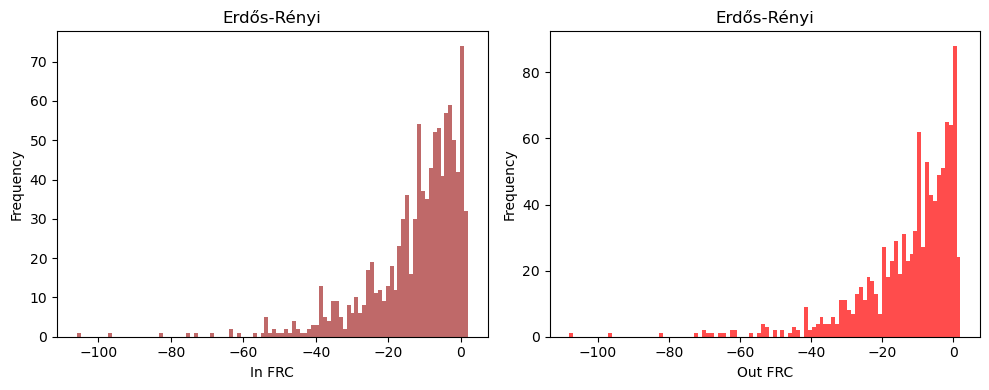

In [10]:
# Plot curvature distributions for Erdős-Rényi model
plot_curvature_distributions(G_er, "Erdős-Rényi", in_color='brown', out_color='red')

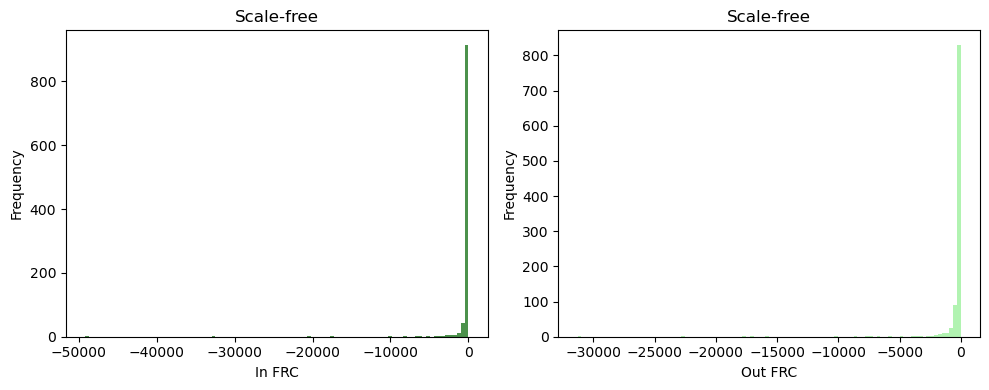

In [11]:
# Plot curvature distributions for Scale-free model
plot_curvature_distributions(G_sf, "Scale-free", in_color='darkgreen', out_color='lightgreen')

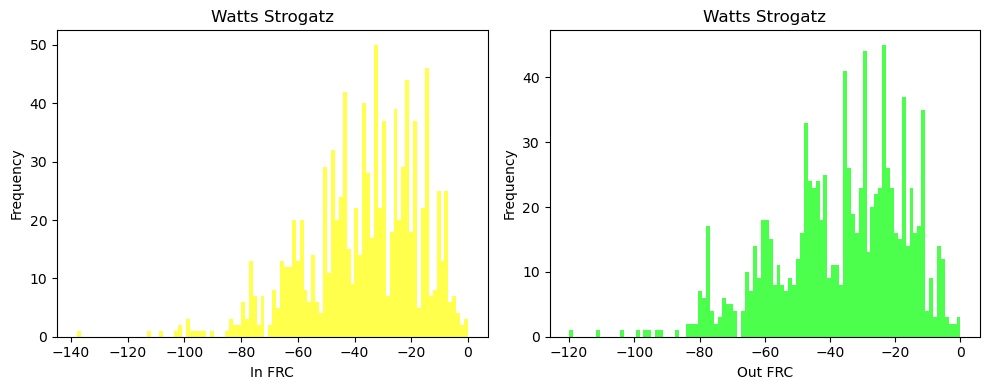

In [12]:
# Plot curvature distributions for Scale-free model
plot_curvature_distributions(G_ws, "Watts Strogatz", in_color='yellow', out_color='lime')

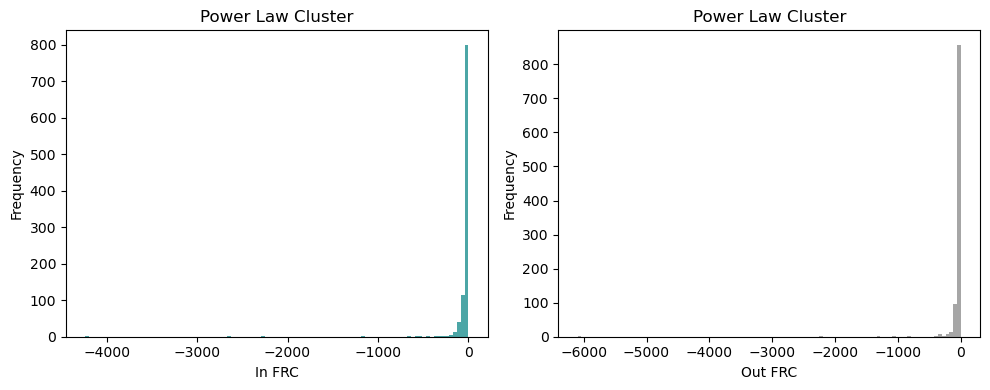

In [13]:
# Plot curvature distributions for Scale-free model
plot_curvature_distributions(G_plc, "Power Law Cluster", in_color='teal', out_color='gray')

### 3. Correlation Analysis between Curvature and Centrality Measures

#### 3.1 Compute Adjacency Matrix of a Directed Network and In and Out Degrees Matrices

In [14]:
def compute_adjacency_matrix(G):
    """
    Compute the adjacency matrix of a directed network.
    """
    return nx.adjacency_matrix(G).todense()

# Example usage
n = 5
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)]
G = nx.DiGraph(edges)

adjacency_matrix = compute_adjacency_matrix(G)
print("Adjacency Matrix:")
print(adjacency_matrix)

Adjacency Matrix:
[[0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [1 0 0 0 0]]


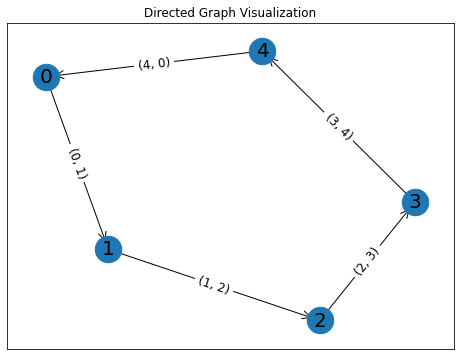

In [15]:
# Draw the directed graph
pos = nx.spring_layout(G)  # positions for all nodes
plt.figure(figsize=(8, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700)

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='->', arrowsize=20)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=20, font_family='sans-serif')

# Draw edge labels (optional)
edge_labels = {edge: f"{edge}" for edge in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

plt.title("Directed Graph Visualization")
plt.show()

In [16]:
class TriangularMatrices:
    def __init__(self, matrix):
        self.matrix = np.array(matrix)
        self.row, self.col = self.matrix.shape
        self.in_degrees = self.get_in_degrees()
        self.out_degrees = self.get_out_degrees()

    def get_in_degrees(self):
        in_degrees = np.zeros((self.row, self.col), dtype=int)
        for i in range(0, self.row):
            for j in range(0, self.col):
                if i >= j:
                    in_degrees[i][j] = self.matrix[i][j]
        return in_degrees

    def get_out_degrees(self):
        out_degrees = np.zeros((self.row, self.col), dtype=int)
        for i in range(0, self.row):
            for j in range(0, self.col):
                if i <= j:
                    out_degrees[i][j] = self.matrix[i][j]
        return out_degrees

# Example usage
tm = TriangularMatrices(adjacency_matrix)
print("In-Degrees Matrix:")
print(tm.in_degrees)
print("Out-Degrees Matrix:")
print(tm.out_degrees)

In-Degrees Matrix:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]
Out-Degrees Matrix:
[[0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 0 0 0 0]]


#### 3.2 Correlation Between In-Forman Vs In-Degree Matrix and Out-Forman and Out-Degree Martrix

In [17]:
# Function to plot correlation between Forman curvature and degree matrices
def plot_correlation(forman_values, degree_matrix, title, color, ax):
    degree_values = degree_matrix.sum(axis=1)
    correlation, _ = pearsonr(forman_values, degree_values)

    ax.scatter(forman_values, degree_values, alpha=0.7, edgecolors='w', s=120, color=color)
    ax.set_title(f'{title}\nPearson Correlation: {correlation:.2f}')
    ax.set_xlabel('FRC')
    ax.set_ylabel('Degree')
    #ax.grid(True)

In [18]:
# Compute Forman-Ricci curvatures and adjacency matrices for Erdős-Rényi network
fr_er = FormanRicciDirected(G_er)
G_er_with_curvature = fr_er.compute_ricci_curvature()
G_er_with_curvature = fr_er.compute_node_curvatures()
adj_matrix_er = compute_adjacency_matrix(G_er)

# Compute Forman-Ricci curvatures and adjacency matrices for Scale-Free network
fr_sf = FormanRicciDirected(G_sf)
G_sf_with_curvature = fr_sf.compute_ricci_curvature()
G_sf_with_curvature = fr_sf.compute_node_curvatures()
adj_matrix_sf = compute_adjacency_matrix(G_sf)

# Compute Forman-Ricci curvatures and adjacency matrices for Watts-Strogatz network
fr_ws = FormanRicciDirected(G_ws)
G_ws_with_curvature = fr_ws.compute_ricci_curvature()
G_ws_with_curvature = fr_ws.compute_node_curvatures()
adj_matrix_ws = compute_adjacency_matrix(G_ws)

# Compute Forman-Ricci curvatures and adjacency matrices for Power-Law Cluster network
fr_plc = FormanRicciDirected(G_plc)
G_plc_with_curvature = fr_plc.compute_ricci_curvature()
G_plc_with_curvature = fr_plc.compute_node_curvatures()
adj_matrix_plc = compute_adjacency_matrix(G_plc)

# Compute degree matrices for all networks
tm_er = TriangularMatrices(adj_matrix_er)
tm_sf = TriangularMatrices(adj_matrix_sf)
tm_ws = TriangularMatrices(adj_matrix_ws)
tm_plc = TriangularMatrices(adj_matrix_plc)

# Extract Forman-Ricci curvatures for nodes for Erdős-Rényi network
in_forman_er = np.array([data for _, data in G_er_with_curvature.nodes(data='FormanCurvatureIn')])
out_forman_er = np.array([data for _, data in G_er_with_curvature.nodes(data='FormanCurvatureOut')])

# Extract Forman-Ricci curvatures for nodes for Scale-Free network
in_forman_sf = np.array([data for _, data in G_sf_with_curvature.nodes(data='FormanCurvatureIn')])
out_forman_sf = np.array([data for _, data in G_sf_with_curvature.nodes(data='FormanCurvatureOut')])

# Extract Forman-Ricci curvatures for nodes for Watts-Strogatz network
in_forman_ws = np.array([data for _, data in G_ws_with_curvature.nodes(data='FormanCurvatureIn')])
out_forman_ws = np.array([data for _, data in G_ws_with_curvature.nodes(data='FormanCurvatureOut')])

# Extract Forman-Ricci curvatures for nodes for Power-Law Cluster network
in_forman_plc = np.array([data for _, data in G_plc_with_curvature.nodes(data='FormanCurvatureIn')])
out_forman_plc = np.array([data for _, data in G_plc_with_curvature.nodes(data='FormanCurvatureOut')])


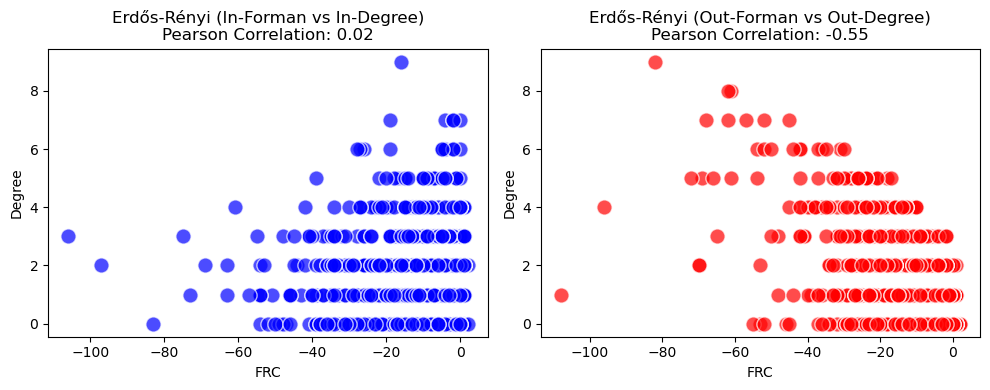

In [19]:
# Plotting for Erdős-Rényi model
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi = 100)
axs = axs.flatten()  # Flatten the array for easy iteration
plot_correlation(in_forman_er, tm_er.in_degrees, 'Erdős-Rényi (In-Forman vs In-Degree)', 'blue', axs[0])
plot_correlation(out_forman_er, tm_er.out_degrees, 'Erdős-Rényi (Out-Forman vs Out-Degree)', 'red', axs[1])

plt.tight_layout()
plt.show()


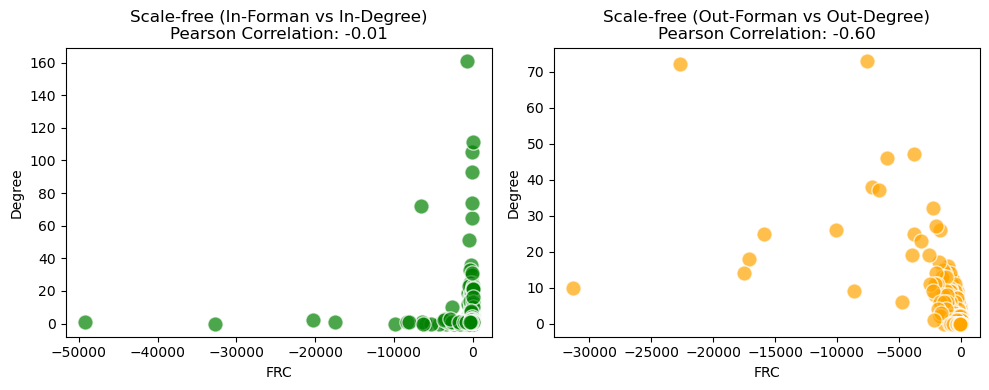

In [20]:
# Plotting for Scale-free model
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi = 100)
axs = axs.flatten()  # Flatten the array for easy iteration

plot_correlation(in_forman_sf, tm_sf.in_degrees, 'Scale-free (In-Forman vs In-Degree)', 'green', axs[0])
plot_correlation(out_forman_sf, tm_sf.out_degrees, 'Scale-free (Out-Forman vs Out-Degree)', 'orange', axs[1])

plt.tight_layout()

# Save the figure in high resolution (300 dpi)
#fig.savefig("images/scale_free_forman_vs_degree.png")
plt.show()

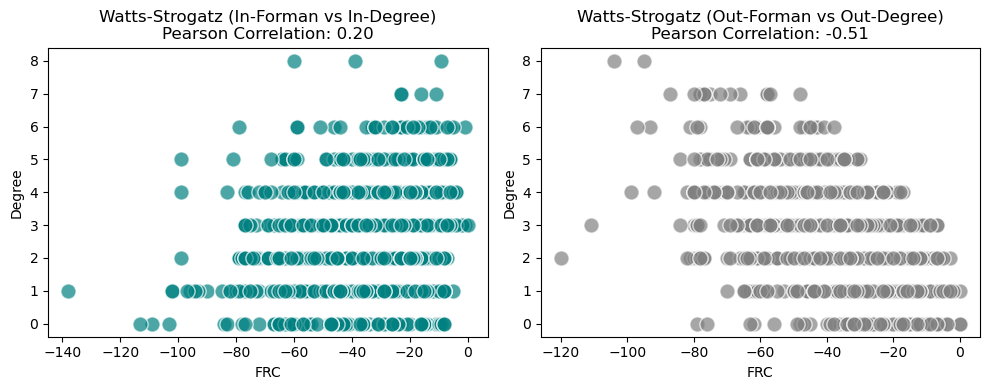

In [21]:
# Plotting for Watts-Strogatz Model
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi = 100)
axs = axs.flatten()  # Flatten the array for easy iteration

# Replace variables with Watts-Strogatz specific data
plot_correlation(in_forman_ws, tm_ws.in_degrees, 'Watts-Strogatz (In-Forman vs In-Degree)', 'teal', axs[0])
plot_correlation(out_forman_ws, tm_ws.out_degrees, 'Watts-Strogatz (Out-Forman vs Out-Degree)', 'gray', axs[1])

plt.tight_layout()

# Save the figure in high resolution
#fig.savefig("images/watts_strogatz_forman_vs_degree.png")
plt.show()

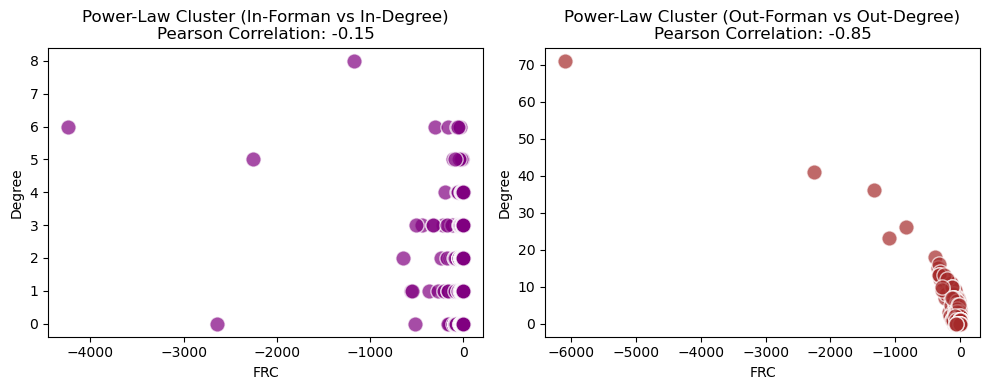

In [22]:
# Plotting for Power-Law Cluster Model
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi = 100)
axs = axs.flatten()  # Flatten the array for easy iteration

# Replace variables with Power-Law Cluster specific data
plot_correlation(in_forman_plc, tm_plc.in_degrees, 'Power-Law Cluster (In-Forman vs In-Degree)', 'purple', axs[0])
plot_correlation(out_forman_plc, tm_plc.out_degrees, 'Power-Law Cluster (Out-Forman vs Out-Degree)', 'brown', axs[1])

plt.tight_layout()

# Save the figure in high resolution
#fig.savefig("images/power_law_cluster_forman_vs_degree.png")
plt.show()

### 4. Simulation of SIR Models with Curvature-Dependent Transmission Rates

In [23]:
# Parameters for SIR model
beta_0_values = [0.1, 0.3, 0.5, 0.7]
gamma = 0.1
T = 100
t = np.linspace(0, T, 500)
dt = 0.01

def sir_model(y, t, beta_0, gamma, B, n):
    S, I, R = y[:n], y[n:2*n], y[2*n:]
    infection_force = B @ I
    dSdt = -S * infection_force
    dIdt = S * infection_force - gamma * I
    dRdt = gamma * I
    return np.concatenate([dSdt, dIdt, dRdt])

def simulate_sir_directed_model(G, model_name="Directed Network"):
    # Check input type
    if not isinstance(G, nx.DiGraph):
        raise TypeError("G must be a NetworkX DiGraph (directed graph).")

    # Compute Forman-Ricci curvature
    fr = FormanRicciDirected(G)
    G = fr.compute_ricci_curvature()

    # Node setup
    node_list = list(G.nodes())
    node_to_index = {node: i for i, node in enumerate(node_list)}
    n = len(node_list)

    # Initial conditions
    S0 = np.full(n, 0.9)
    I0 = np.full(n, 0.1)
    R0 = np.zeros(n)
    initial_conditions = np.concatenate([S0, I0, R0])


    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=100)
    axs = axs.flatten()

    for idx, beta_0 in enumerate(beta_0_values):
        B = np.zeros((n, n))
        for u, v in G.edges():
            i, j = node_to_index[u], node_to_index[v]
            F_uv = G[u][v].get('FormanCurvature', 0.0)
            B[i, j] = beta_0 * np.exp(F_uv)

        np.fill_diagonal(B, 0)

        # Solve the model
        sol = odeint(sir_model, initial_conditions, t, args=(beta_0, gamma, B, n))
        S, I, R = sol[:, :n], sol[:, n:2*n], sol[:, 2*n:]
        S_nodes = np.mean(S, axis=1) * n
        I_nodes = np.mean(I, axis=1) * n
        R_nodes = np.mean(R, axis=1) * n

        axs[idx].plot(t, S_nodes, label='Susceptible', color='blue')
        axs[idx].plot(t, I_nodes, label='Infected', color='red')
        axs[idx].plot(t, R_nodes, label='Recovered', color='green')
        axs[idx].set_title(f'{model_name} (β={beta_0})', fontsize=10)
        axs[idx].set_xlabel('Time')
        axs[idx].set_ylabel('Population')
        axs[idx].legend(fontsize=8)
        axs[idx].tick_params(labelsize=8)
       # axs[idx].grid(True)

    #plt.suptitle(f'SIR Dynamics with Directed FRC on {model_name}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

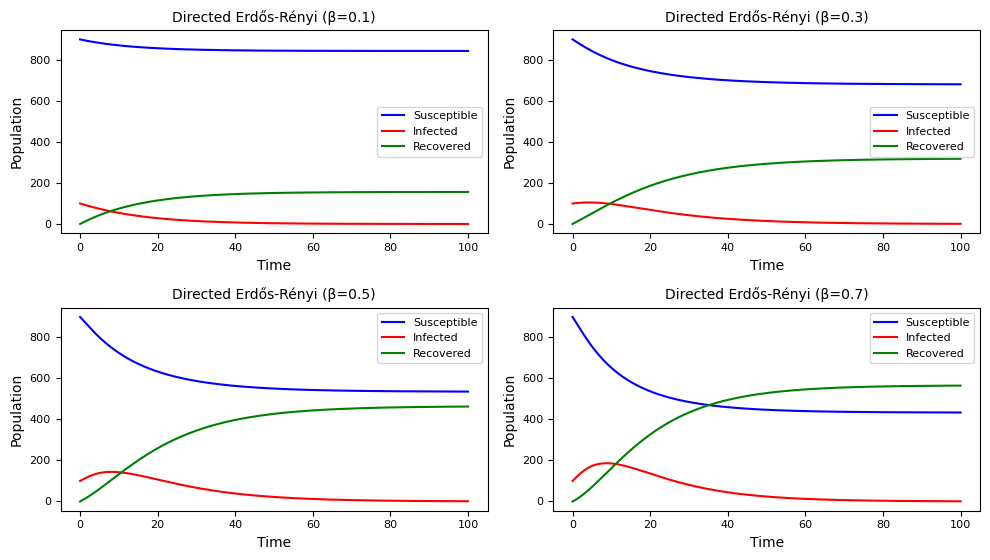

In [24]:
simulate_sir_directed_model(G_er, "Directed Erdős-Rényi")

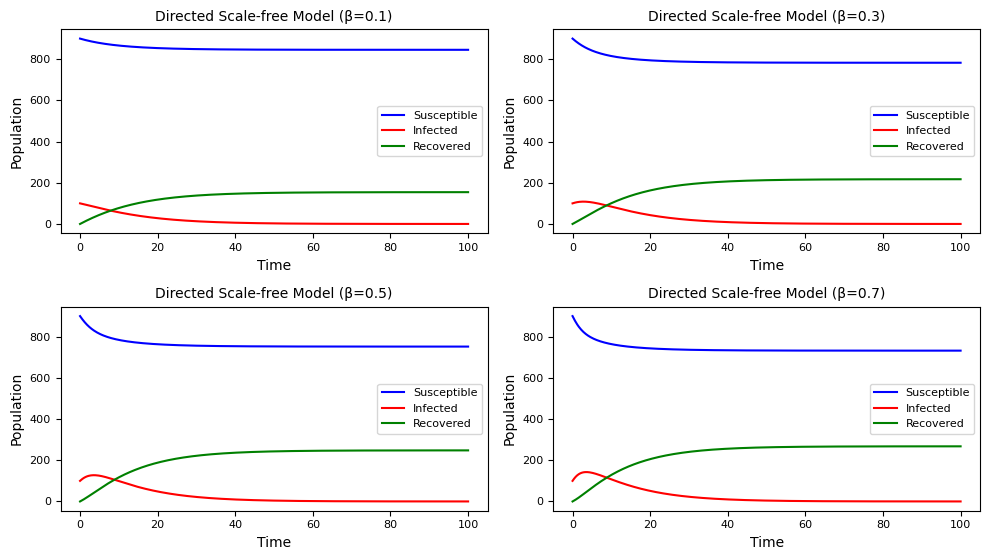

In [25]:
# Simulate the SIR model for the directed Scale-free  network
simulate_sir_directed_model(G_sf, "Directed Scale-free Model")

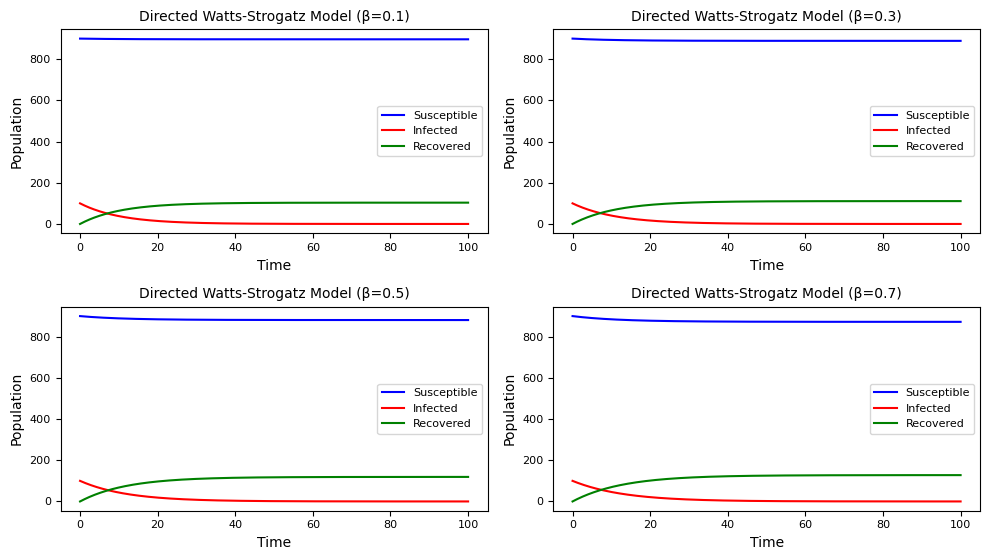

In [26]:
# Simulate the SIR model for the directed Watts Strogatz network
simulate_sir_directed_model(G_ws, "Directed Watts-Strogatz Model")

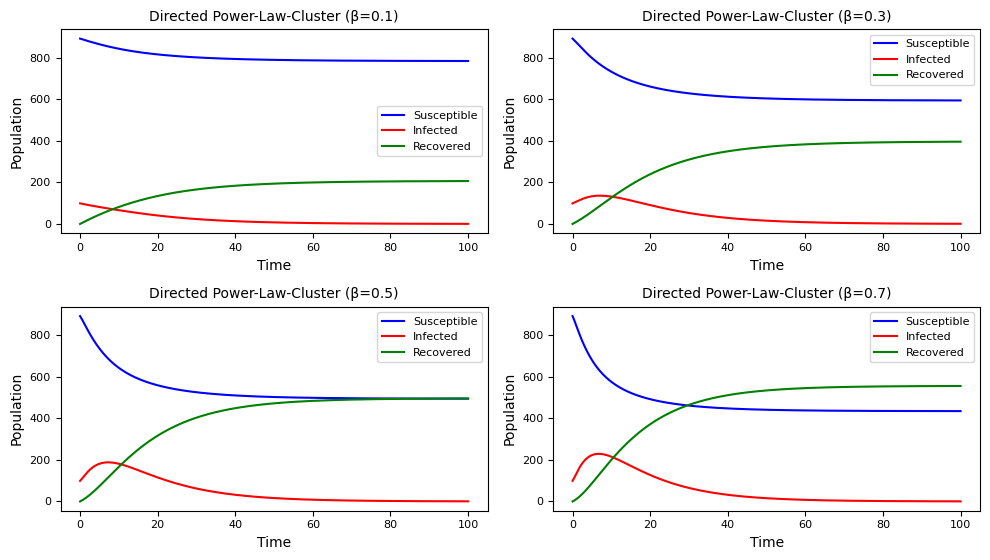

In [27]:
# Simulate the SIR model for the directed Power-Law-Cluster network
simulate_sir_directed_model(G_plc, "Directed Power-Law-Cluster")

### Infected Dynamics across the Four Models

In [28]:
# Main simulation function
def simulate_sir_directed_model(G_input, model_name="Directed Network"):
    if not isinstance(G_input, nx.DiGraph):
        raise TypeError("G must be a NetworkX DiGraph (directed graph).")

    # Create a fresh copy of the input graph
    G = G_input.copy()

    # Compute Forman-Ricci curvature
    fr = FormanRicciDirected(G)
    G = fr.compute_ricci_curvature()

    # Node setup
    node_list = list(G.nodes())
    node_to_index = {node: i for i, node in enumerate(node_list)}
    n = len(node_list)

    # Initial conditions
    S0 = np.full(n, 0.9)
    I0 = np.full(n, 0.1)
    R0 = np.zeros(n)
    initial_conditions = np.concatenate([S0, I0, R0])

    # Subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=100)
    axs = axs.flatten()

    for idx, beta_0 in enumerate(beta_0_values):
        # Compute transmission matrix B
        B = np.zeros((n, n))
        for u, v in G.edges():
            i = node_to_index[u]
            j = node_to_index[v]
            F_uv = G[u][v].get('FormanCurvature', 0.0)
            B[i, j] = beta_0 * np.exp(F_uv)
        np.fill_diagonal(B, 0)

        # Solve ODE
        sol = odeint(sir_model, initial_conditions, t, args=(beta_0, gamma, B, n))
        I = sol[:, n:2*n]
        I_mean = np.mean(I, axis=1) * n

        # Plot only infected class
        axs[idx].plot(t, I_mean, label='Infected', color='red')
        axs[idx].set_title(f'{model_name} (β={beta_0})', fontsize=10)
        axs[idx].set_xlabel('Time')
        axs[idx].set_ylabel('Number Infected')
        axs[idx].legend(fontsize=8)
        axs[idx].tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

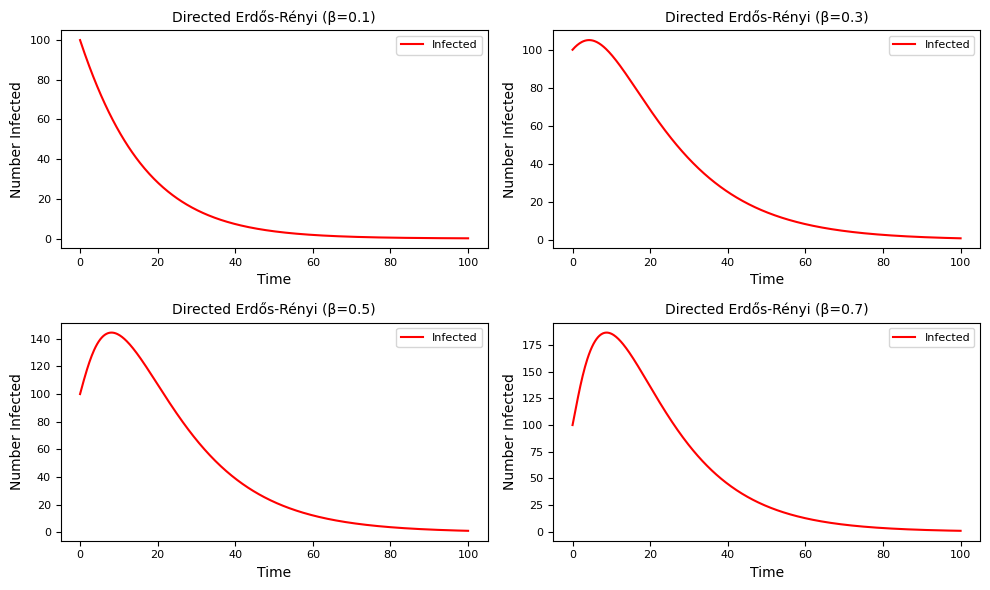

In [29]:
simulate_sir_directed_model(G_er, model_name="Directed Erdős-Rényi")

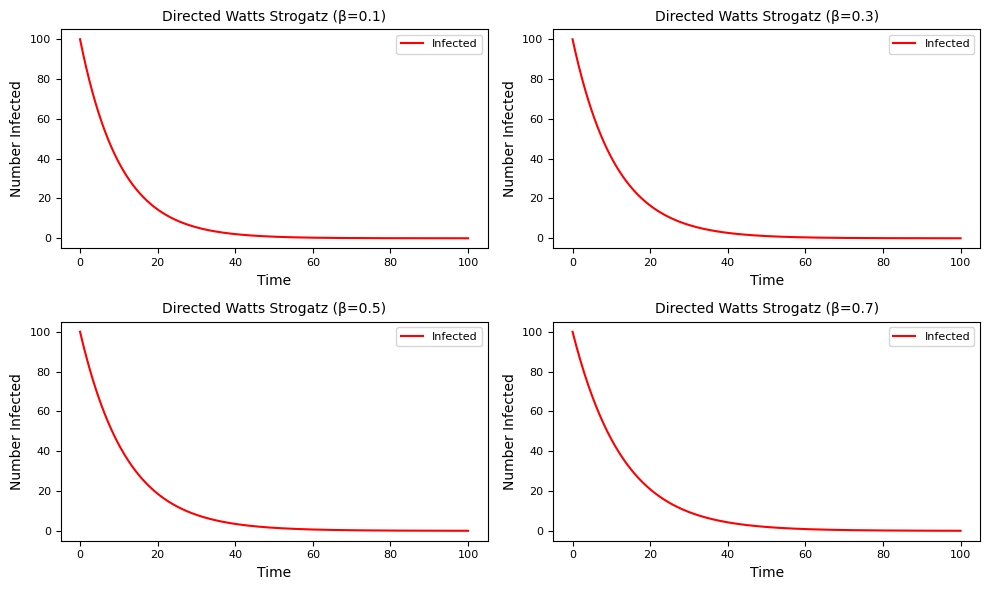

In [30]:
simulate_sir_directed_model(G_ws, model_name="Directed Watts Strogatz")

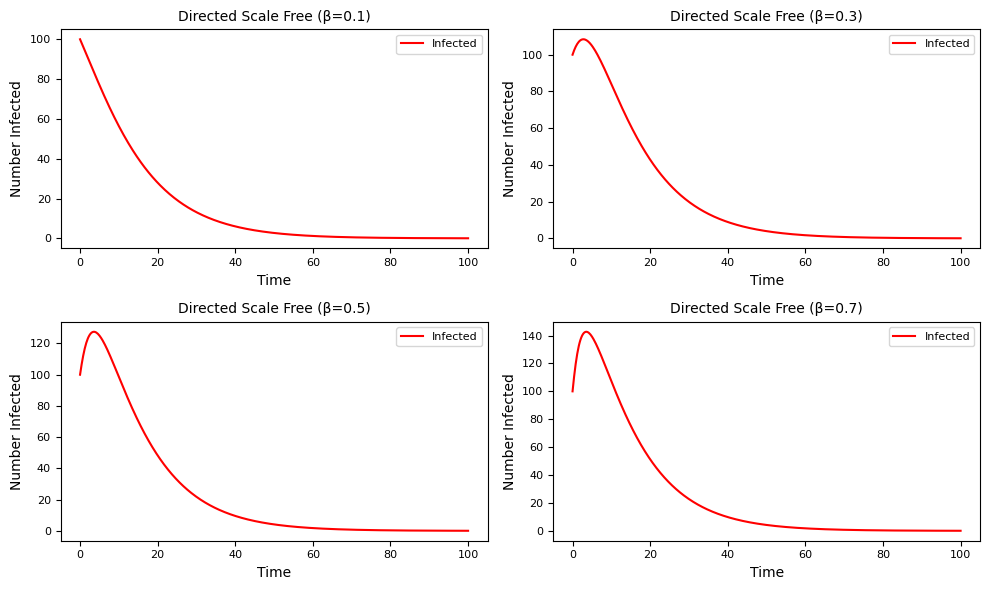

In [31]:
simulate_sir_directed_model(G_sf, model_name="Directed Scale Free")

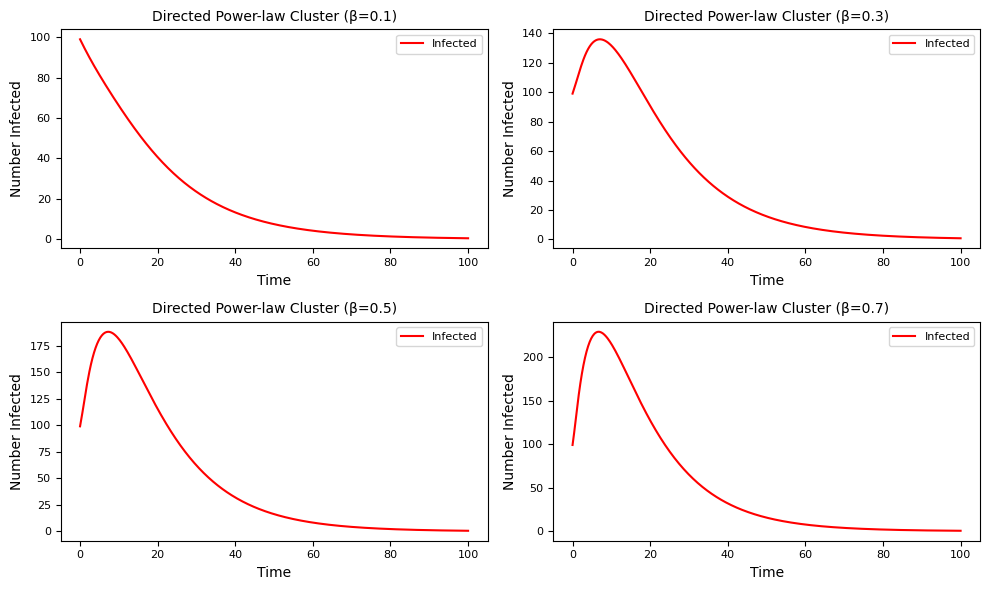

In [32]:
simulate_sir_directed_model(G_plc, model_name="Directed Power-law Cluster")

### 5. Comparison with Traditional SIR Models

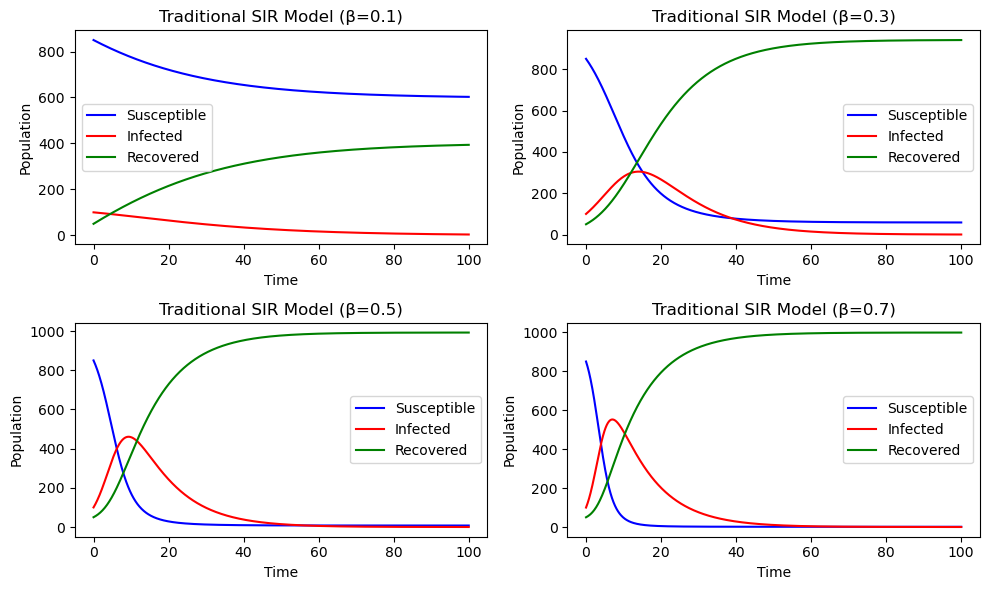

In [33]:
# Function to define the ODEs for the SIR model
def sir_ode(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Function to solve the SIR model using odeint
def traditional_SIR_model(N, beta, gamma, T, dt):
    # Initial conditions: Set initial infected to 100 individuals, and recovered to 5% of the population
    S0 = N - 100 - int(0.05 * N)
    I0 = 100
    R0 = int(0.05 * N)
    y0 = [S0, I0, R0]

    # Time points at which to solve
    t = np.linspace(0, T, int(T / dt))

    # Solve ODE using odeint
    ret = odeint(sir_ode, y0, t, args=(N, beta, gamma))
    S_t, I_t, R_t = ret.T  # Transpose to get each variable separately

    return t, S_t, I_t, R_t

# Function to plot SIR dynamics using subplots
def plot_SIR_dynamics_subplots(t, S_t_list, I_t_list, R_t_list, beta_0_values):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)
    axs = axs.flatten()  # Flatten the array for easy iteration

    for i, (S_t, I_t, R_t, beta_0) in enumerate(zip(S_t_list, I_t_list, R_t_list, beta_0_values)):
        axs[i].plot(t, S_t, label='Susceptible', color='blue')
        axs[i].plot(t, I_t, label='Infected', color='red')
        axs[i].plot(t, R_t, label='Recovered', color='green')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Population')
        axs[i].set_title(f'Traditional SIR Model (β={beta_0})')
        axs[i].legend()
        #axs[i].grid(True)

    plt.tight_layout()

    # Save the figure in high resolution (300 dpi)
    #fig.savefig("images/traditional_sir_dynamics_comparison.png", dpi=300)

    plt.show()

# Parameters
beta_0_values = [0.1, 0.3, 0.5, 0.7]
S_t_list, I_t_list, R_t_list = [], [], []

# Number of individuals
N = 1000
T = 100  # Total time for the simulation
dt = 0.1  # Time step
gamma = 0.1  # Recovery rate

# Run simulations for different beta_0 values
for beta_0 in beta_0_values:
    t, S_t, I_t, R_t = traditional_SIR_model(N, beta_0, gamma, T, dt)
    S_t_list.append(S_t)
    I_t_list.append(I_t)
    R_t_list.append(R_t)

# Plot all results in a single figure with subplots
plot_SIR_dynamics_subplots(t, S_t_list, I_t_list, R_t_list, beta_0_values)

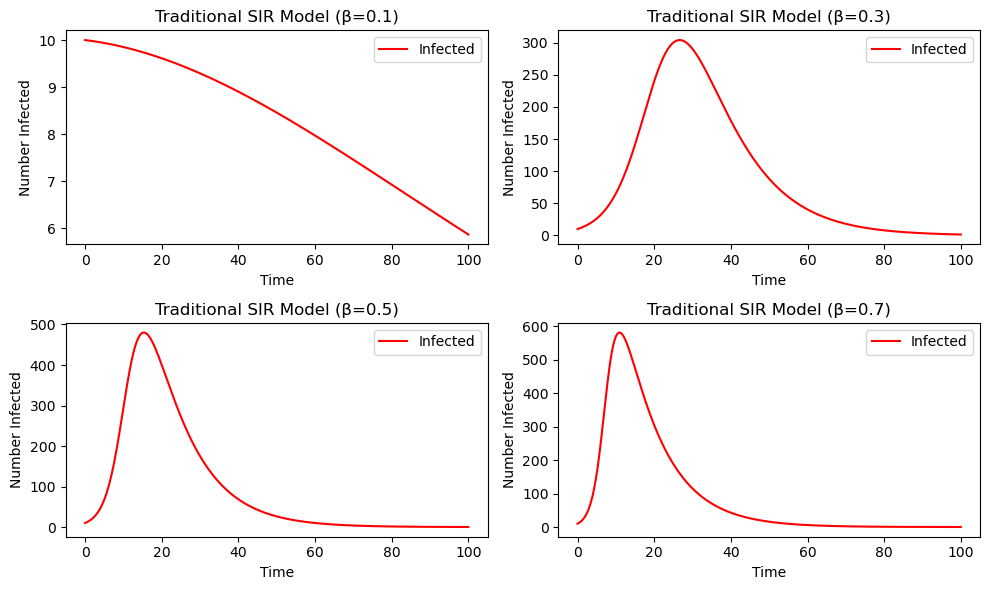

In [34]:
# Define the traditional SIR model
# dS/dt = -beta_0 * S * I / N
# dI/dt = beta_0 * S * I / N - gamma * I
# dR/dt = gamma * I
def sir_derivatives(y, t, N, beta_0, gamma):
    S, I, R = y
    dSdt = -beta_0 * S * I / N
    dIdt = beta_0 * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Function to solve the traditional SIR model using odeint
def traditional_SIR_model(N, beta_0, gamma, T, dt):
    # Initial conditions: S0, I0, R0
    S0 = 0.99 * N
    I0 = 0.01 * N
    R0 = 0.0
    y0 = S0, I0, R0

    # Time points for the integration
    t = np.linspace(0, T, int(T / dt) + 1)

    # Solve the SIR differential equations
    ret = odeint(sir_derivatives, y0, t, args=(N, beta_0, gamma))
    S, I, R = ret.T

    return t, S, I, R

# Plotting function for traditional SIR model
# Plots the infected population for different beta_0 values
def plot_SIR_dynamics_subplots(t, I_t_list, beta_0_values):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)
    axs = axs.flatten()  # Flatten the array for easy iteration

    for i, (I_t, beta_0) in enumerate(zip(I_t_list, beta_0_values)):
        axs[i].plot(t, I_t, label='Infected', color='red')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Number Infected')
        axs[i].set_title(f'Traditional SIR Model (β={beta_0})')
        axs[i].legend()
        #axs[i].grid(True)

    plt.tight_layout()

    # Save the figure in high resolution (300 dpi)
    #fig.savefig("images/traditional_sir_infected_dynamics_comparison.png", dpi=300)

    plt.show()

# Parameters
beta_0_values = [0.1, 0.3, 0.5, 0.7]
I_t_list = []

# Number of individuals
N = 1000
T = 100  # Total time for the simulation
dt = 0.1  # Time step
gamma = 0.1  # Recovery rate

# Run simulations for different beta_0 values
for beta_0 in beta_0_values:
    t, S_t, I_t, R_t = traditional_SIR_model(N, beta_0, gamma, T, dt)
    I_t_list.append(I_t)

# Plot only the infected population in subplots
plot_SIR_dynamics_subplots(t, I_t_list, beta_0_values)